In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split, ParameterGrid, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, precision_score, confusion_matrix, classification_report, make_scorer
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [254]:
df = pd.read_csv('../results/entry_tracking.csv')
games = pd.read_parquet('../data/games.parquet', engine="pyarrow")
games = games[['game_id', 'game_date']]

df = pd.merge(df, games, on='game_id', how='left').sort_values(by='game_date', ascending=True)
df = df[(df['duration'] < 120) & (df['period']<4)]
df = df[['game_id', 'game_date','team_id', 'opp_team_id', 'player_id', 'ozpt', 'period', 'event_type', 'entry_type', 'puck_carrier_x', 'puck_carrier_y', 'puck_carrier_vel_x', 'puck_carrier_vel_y', 'carrier_dist_from_blueline', 'non_carrier_vel_x', 'non_carrier_near_ozone', 'non_carrier_near_dzone', 'non_carrier_in_dzone', 'opponent_vel_x', 'opponent_near_ozone', 'opponent_near_dzone', 'opponent_in_dzone']].dropna()


In [60]:
# Use log-transform optionally if you want more stable training
y = df['ozpt']              # original seconds
y_log = np.log1p(y)         # for proportional error training


In [61]:
categorical_columns = ['entry_type', 'period']
X = df[['period', 'entry_type',
        'puck_carrier_x', 'puck_carrier_y',
        'puck_carrier_vel_x', 'puck_carrier_vel_y',
        'carrier_dist_from_blueline',
        'non_carrier_vel_x', 'non_carrier_near_ozone',
        'non_carrier_near_dzone', 'non_carrier_in_dzone',
        'opponent_vel_x', 'opponent_near_ozone', 
        'opponent_near_dzone', 'opponent_in_dzone']]

In [62]:
from sklearn.preprocessing import LabelEncoder
x_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    x_encoders[col] = le


C:\Users\Flodh\AppData\Local\Temp\ipykernel_9868\1239476216.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\Flodh\AppData\Local\Temp\ipykernel_9868\1239476216.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.20, random_state=27
)


In [64]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=27
)


In [65]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [4,6,7,8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300,500,700]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=27,
    n_jobs=-1
)

random_search.fit(X_train, y_train_log)
best_model = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [202]:
import numpy as np

y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # back to seconds


In [203]:
# Residuals in log space
residuals = y_train_log - best_model.predict(X_train)

# Smearing factor
smear = np.mean(np.exp(residuals))

# Corrected predictions
y_pred = np.expm1(y_pred_log) * smear


In [204]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
rho, _ = spearmanr(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("Spearman rho:", rho)

# Calibration check (bins)
import pandas as pd
df_eval = pd.DataFrame({"pred": y_pred, "true": y_test})
df_eval["bin"] = pd.qcut(df_eval["pred"], 10)
print(df_eval.groupby("bin")["true"].mean())


RMSE: 7.6815356757339295
MAE: 4.979981095517867
Spearman rho: 0.43882274873455707
bin
(0.553, 1.499]     2.046471
(1.499, 1.95]      3.012653
(1.95, 2.464]      3.260573
(2.464, 3.553]     4.168760
(3.553, 5.872]     6.386947
(5.872, 6.425]     5.638853
(6.425, 6.757]     5.838360
(6.757, 7.13]      7.085027
(7.13, 7.781]      7.791493
(7.781, 12.271]    9.509587
Name: true, dtype: float64


c:\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Flodh\AppData\Local\Temp\ipykernel_9868\708705955.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_eval.groupby("bin")["true"].mean())


<Figure size 1000x800 with 0 Axes>

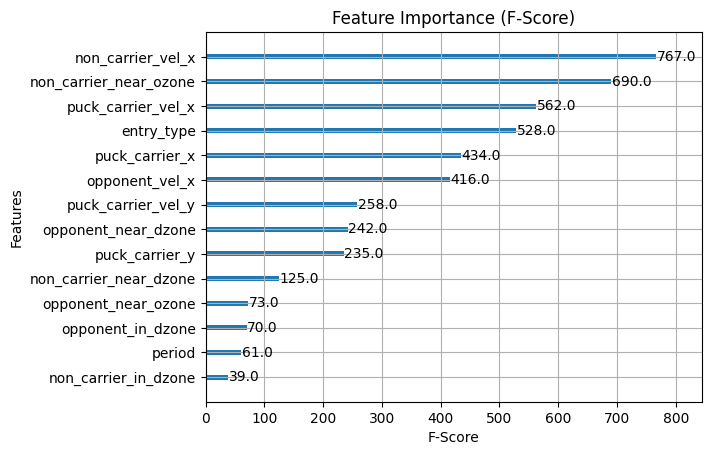

In [251]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(best_model, max_num_features=20)
plt.xlabel("F-Score")
plt.title("Feature Importance (F-Score)")
plt.show()


In [206]:
# Add predicted xOZPT to full dataset
# df["xOZPT"] = np.expm1(best_model.predict(np.array(X)))

# Log predictions
pred_log = best_model.predict(np.array(X))

# Apply smearing correction
df["xOZPT"] = np.expm1(pred_log) * smear


# Residual = actual - expected
df["OZPT_residual"] = df["ozpt"] - df["xOZPT"]

# Aggregate by team
team_performance = df.groupby(["team_id", "game_id"])["OZPT_residual"].sum().sort_values(ascending=False)
print(team_performance)


team_id                               game_id                             
89d6fd61-dc6a-4969-d01a-a672c177757f  3dc0fff5-d32f-e952-131c-de3998c6e76d    236.343089
                                      3840373a-4f02-5262-a8c3-3b0a2b8c4625    216.443768
01eca08e-da2c-37e0-ec2b-1cbb68087b57  c1f48d75-571b-b5c0-136e-007d9b1b8df9    209.308572
e6941978-f451-5cf4-3e1a-b1d194ee998c  bd38b1db-d0d9-f2d3-42b5-6e2028732e62    205.634270
9c9ce715-dcef-1692-1850-eba56333387b  eb7285b7-eedf-f667-00b3-77d9fd81eed7    196.262554
                                                                                 ...    
d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019  48796a90-f8e2-5301-0b1d-3cf2673b7f3c   -112.232092
8dbadcf1-c49b-6e64-a846-b145c2c5a426  99b7644c-b2ea-dcff-0ecf-0733b033ac19   -113.856411
5044a67e-1e6c-ca03-d6ea-fc7ce424758f  076e3cb2-02fb-069f-cb82-a45c5a432ed1   -117.755872
d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019  a7a9a25a-af32-a6b9-247c-b30a2242832f   -125.523588
971502f4-80be-6e90-0bfb-3a60367a24f

In [222]:
midpoint = len(df) // 2

df = df.sort_values(by='game_date', ascending=True)
# Split bottom and bottom
top_half = df.iloc[:midpoint]
bottom_half = df.iloc[midpoint:]

In [223]:
team_summary = (
    df.groupby(["team_id", "entry_type"])
      .agg(
          entries=("ozpt", "count"),
        #   ozpt=("ozpt", "mean"),
        #   xozpt=("xOZPT", "mean"),
          ozpt_above_exp=("OZPT_residual", "mean")
      )
      .sort_values("ozpt_above_exp", ascending=False)
).reset_index()

team_summary

,team_id,entry_type,entries,ozpt_above_exp
0,19188913-73c8-34a7-d02a-5d1c3e58a191,carry_3on1,1,14.663154
1,e6941978-f451-5cf4-3e1a-b1d194ee998c,carry,7,12.091146
2,971502f4-80be-6e90-0bfb-3a60367a24ff,carry_1on0,2,11.060160
3,971502f4-80be-6e90-0bfb-3a60367a24ff,carry_3on1,3,6.306942
4,01eca08e-da2c-37e0-ec2b-1cbb68087b57,carry,8,5.774355
...,...,...,...,...
345,19188913-73c8-34a7-d02a-5d1c3e58a191,carry,5,-4.092020
346,6cac12e2-0546-2c1a-689f-ab26d8a6355a,carry_1on0,5,-4.315283
347,fbd255f8-427d-f29b-e83e-6c631c75899a,carry_3on1,2,-4.579292
348,5044a67e-1e6c-ca03-d6ea-fc7ce424758f,carry_3on1,4,-5.056854


In [224]:
top_team_summary = (
    top_half.groupby(["team_id", 'game_id'])
      .agg(
          top_half_entries=("ozpt", "count"),
          top_half_ozpt=("ozpt", "sum"),
          top_half_xozpt=("xOZPT", "sum"),
          top_half_ozptax=("OZPT_residual", "sum")
      )
      # .sort_values("top_half_ozpt_above_exp", ascending=False)
).reset_index()

top_team_summary = top_team_summary.groupby('team_id').agg({'top_half_ozpt':'mean','top_half_xozpt':'mean', 'top_half_ozptax':'mean'}).reset_index()
top_team_summary

,team_id,top_half_ozpt,top_half_xozpt,top_half_ozptax
0,01eca08e-da2c-37e0-ec2b-1cbb68087b57,296.558462,236.493729,60.064728
1,08dc0c28-d913-12fb-f899-7b366b3a2f65,189.338333,203.397079,-14.058740
2,09511ef6-c070-3407-376e-7c3df0cc00f7,153.370000,178.926056,-25.556065
3,19188913-73c8-34a7-d02a-5d1c3e58a191,165.552308,157.526993,8.025312
4,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,182.900769,183.259628,-0.358860
5,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,250.647647,201.957581,48.690074
6,28147617-6a1a-8547-8b07-b84f5d0807c5,268.666250,261.939819,6.726419
7,2fddd6bd-144f-ca64-90e3-8d36f96c8b28,196.602222,164.179733,32.422500
8,411d86dc-8d7b-5507-c28d-87aa160b61cc,207.083333,204.704880,2.378455
9,50030ea0-2c9b-66e2-a36c-bab16b79492c,156.714615,176.308731,-19.594112


In [225]:
bottom_team_summary = (
    bottom_half.groupby(["team_id", "game_id"])
      .agg(
          bottom_half_entries=("ozpt", "count"),
          bottom_half_ozpt=("ozpt", "sum"),
          bottom_half_xozpt=("xOZPT", "sum"),
          bottom_half_ozptax=("OZPT_residual", "sum")
      )
      # .sort_values("bottom_half_ozpt_above_exp", ascending=False)
).reset_index()

bottom_team_summary = bottom_team_summary.groupby('team_id').agg({'bottom_half_ozpt':'mean', 'bottom_half_xozpt':'mean', 'bottom_half_ozptax':'mean'}).reset_index()
bottom_team_summary

,team_id,bottom_half_ozpt,bottom_half_xozpt,bottom_half_ozptax
0,01eca08e-da2c-37e0-ec2b-1cbb68087b57,240.636471,222.998413,17.638049
1,08dc0c28-d913-12fb-f899-7b366b3a2f65,169.586667,182.360733,-12.774064
2,09511ef6-c070-3407-376e-7c3df0cc00f7,181.469000,165.405396,16.063607
3,19188913-73c8-34a7-d02a-5d1c3e58a191,198.048824,165.255798,32.793018
4,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,208.862778,199.951263,8.911508
5,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,243.898571,204.819534,39.079040
6,28147617-6a1a-8547-8b07-b84f5d0807c5,275.070667,252.619476,22.451195
7,2fddd6bd-144f-ca64-90e3-8d36f96c8b28,225.086923,170.439240,54.647675
8,411d86dc-8d7b-5507-c28d-87aa160b61cc,242.204615,189.724396,52.480205
9,50030ea0-2c9b-66e2-a36c-bab16b79492c,182.710556,149.532822,33.177733


In [226]:
split_team_summary = pd.merge(top_team_summary, bottom_team_summary, on=['team_id'], how='left')

In [227]:
print(split_team_summary)

                                 team_id  top_half_ozpt  top_half_xozpt  \
0   01eca08e-da2c-37e0-ec2b-1cbb68087b57     296.558462      236.493729   
1   08dc0c28-d913-12fb-f899-7b366b3a2f65     189.338333      203.397079   
2   09511ef6-c070-3407-376e-7c3df0cc00f7     153.370000      178.926056   
3   19188913-73c8-34a7-d02a-5d1c3e58a191     165.552308      157.526993   
4   1f9a39ec-18eb-166c-d1ed-5dfb9343f764     182.900769      183.259628   
5   2251a5f6-9710-c610-8d44-9f2e4f4fc7a2     250.647647      201.957581   
6   28147617-6a1a-8547-8b07-b84f5d0807c5     268.666250      261.939819   
7   2fddd6bd-144f-ca64-90e3-8d36f96c8b28     196.602222      164.179733   
8   411d86dc-8d7b-5507-c28d-87aa160b61cc     207.083333      204.704880   
9   50030ea0-2c9b-66e2-a36c-bab16b79492c     156.714615      176.308731   
10  5044a67e-1e6c-ca03-d6ea-fc7ce424758f     201.363889      175.550293   
11  67c5ed49-a598-0057-310c-c709186007ab     200.480000      187.872253   
12  6811199d-a914-d1b2-ff

In [238]:
from scipy.stats import spearmanr

rho, _ = spearmanr(split_team_summary['bottom_half_ozptax'], split_team_summary['top_half_ozptax'])
print(rho)


0.3170821114369501


In [229]:
player_summary = (
    df.groupby(["player_id"])
      .agg(
          entries=("ozpt", "count"),
        #   ozpt=("ozpt", "mean"),
          xozpt=("xOZPT", "sum"),
          # ozpt_above_exp=("OZPT_residual", "mean")
      )
      .sort_values("xozpt", ascending=False)
).reset_index()

print(player_summary[player_summary['entries']>20])


                                player_id  entries        xozpt
0    5a453d9b-d3e9-d3cf-af18-be043e9650b3      209  1126.664062
1    41273737-16e3-50f4-d08a-03a1fc11edf5      189   923.276062
2    c5c3387a-6e3e-1ae9-824c-315974f6414e      166   879.942017
3    b2485777-a1f9-23e9-5c28-c99761cd10e2      186   877.657715
4    9daae941-4f95-c94c-baf7-a520ad42785f      175   845.418457
..                                    ...      ...          ...
541  ea7c79f4-a992-0dfc-7f0c-913a5c701c2f       22    98.763824
547  c10719af-87b4-f64d-abda-4dd75b197b9d       23    95.803192
552  c50ee147-78c1-e97c-f042-2810c51adffc       21    90.134377
554  1b8bd0ac-fac4-d900-2d3e-411db1939181       22    89.574692
556  f2bc8771-8044-2f22-b289-2e910a46dfce       22    86.823975

[542 rows x 3 columns]


In [230]:
print("Mean actual:", y.mean())
print("Mean predicted:", df["xOZPT"].mean())

Mean actual: 5.48720794454812
Mean predicted: 4.921214


In [231]:
top_team_defense_summary = (
    top_half.groupby(["opp_team_id", 'game_id'])
      .agg(
          top_half_entries=("ozpt", "count"),
          top_half_ozpt=("ozpt", "sum"),
          top_half_xozpt=("xOZPT", "sum"),
          top_half_ozptax=("OZPT_residual", "sum")
      )
      # .sort_values("top_half_ozpt_above_exp", ascending=False)
).reset_index()

top_team_defense_summary = top_team_defense_summary.groupby('opp_team_id').agg({'top_half_ozpt':'mean','top_half_xozpt':'mean', 'top_half_ozptax':'mean'}).reset_index()
top_team_defense_summary.head()

,opp_team_id,top_half_ozpt,top_half_xozpt,top_half_ozptax
0,01eca08e-da2c-37e0-ec2b-1cbb68087b57,268.511538,249.357178,19.154356
1,08dc0c28-d913-12fb-f899-7b366b3a2f65,225.025000,205.413635,19.611363
2,09511ef6-c070-3407-376e-7c3df0cc00f7,248.231000,215.256470,32.974528
3,19188913-73c8-34a7-d02a-5d1c3e58a191,255.265385,208.204559,47.060833
4,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,205.563077,185.430145,20.132943


In [232]:
bottom_team_defense_summary = (
    bottom_half.groupby(["opp_team_id", 'game_id'])
      .agg(
          bottom_half_entries=("ozpt", "count"),
          bottom_half_ozpt=("ozpt", "sum"),
          bottom_half_xozpt=("xOZPT", "sum"),
          bottom_half_ozptax=("OZPT_residual", "sum")
      )
      # .sort_values("top_half_ozpt_above_exp", ascending=False)
).reset_index()

bottom_team_defense_summary = bottom_team_defense_summary.groupby('opp_team_id').agg({'bottom_half_ozpt':'mean','bottom_half_xozpt':'mean', 'bottom_half_ozptax':'mean'}).reset_index()
bottom_team_defense_summary.head()

,opp_team_id,bottom_half_ozpt,bottom_half_xozpt,bottom_half_ozptax
0,01eca08e-da2c-37e0-ec2b-1cbb68087b57,218.154706,225.521393,-7.366686
1,08dc0c28-d913-12fb-f899-7b366b3a2f65,203.568889,192.194489,11.374399
2,09511ef6-c070-3407-376e-7c3df0cc00f7,214.512857,191.184998,23.327856
3,19188913-73c8-34a7-d02a-5d1c3e58a191,241.295294,200.205063,41.090231
4,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,167.632778,166.810287,0.822491


In [233]:
split_team_defense_summary = pd.merge(top_team_defense_summary, bottom_team_defense_summary, on=['opp_team_id'], how='left')

In [240]:
rho, _ = spearmanr(split_team_defense_summary['bottom_half_ozptax'], split_team_defense_summary['top_half_ozptax'])
print(rho)


0.5168621700879765


In [235]:
df.columns

Index(['game_id', 'game_date', 'team_id', 'opp_team_id', 'player_id', 'ozpt',
       'period', 'event_type', 'entry_type', 'puck_carrier_x',
       'puck_carrier_y', 'puck_carrier_vel_x', 'puck_carrier_vel_y',
       'carrier_dist_from_blueline', 'non_carrier_vel_x',
       'non_carrier_near_ozone', 'non_carrier_near_dzone',
       'non_carrier_in_dzone', 'opponent_vel_x', 'opponent_near_ozone',
       'opponent_near_dzone', 'opponent_in_dzone', 'xOZPT', 'OZPT_residual'],
      dtype='object')

In [252]:
teams = pd.read_parquet('../data/teams.parquet', engine="pyarrow")
players = pd.read_parquet('../data/players.parquet', engine="pyarrow")

FileNotFoundError: [Errno 2] No such file or directory: '../data/teams.parquet'

In [241]:
df.to_csv('../results/xozpt.csv', index=False)

In [247]:
top_half_dumpins = top_half[top_half['entry_type']=='dumpin']
top_entry_type_summary = (
    top_half_dumpins.groupby(['team_id', 'game_id'])
      .agg(
          top_half_entries=("ozpt", "count"),
          top_half_ozpt=("ozpt", "sum"),
          top_half_xozpt=("xOZPT", "sum"),
          top_half_ozptax=("OZPT_residual", "sum")
      )
      # .sort_values("top_half_ozpt_above_exp", ascending=False)
).reset_index()

top_entry_type_summary = top_entry_type_summary.groupby('team_id').agg({'top_half_ozpt':'mean','top_half_xozpt':'mean', 'top_half_ozptax':'mean'}).reset_index()
top_entry_type_summary.head(15)

,team_id,top_half_ozpt,top_half_xozpt,top_half_ozptax
0,01eca08e-da2c-37e0-ec2b-1cbb68087b57,105.030000,109.200729,-4.170729
1,08dc0c28-d913-12fb-f899-7b366b3a2f65,66.175833,98.204140,-32.028313
2,09511ef6-c070-3407-376e-7c3df0cc00f7,64.503000,105.745682,-41.242684
3,19188913-73c8-34a7-d02a-5d1c3e58a191,50.355385,64.781212,-14.425828
4,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,73.823077,97.347122,-23.524042
5,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,51.732353,75.399040,-23.666685
6,28147617-6a1a-8547-8b07-b84f5d0807c5,66.120000,116.333611,-50.213614
7,2fddd6bd-144f-ca64-90e3-8d36f96c8b28,60.533529,69.715759,-9.182234
8,411d86dc-8d7b-5507-c28d-87aa160b61cc,73.347222,107.469177,-34.121954
9,50030ea0-2c9b-66e2-a36c-bab16b79492c,53.767692,86.315559,-32.547872
